In [132]:
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)

In [133]:
import pandas as pd
from utils import *

In [134]:
df = pd.read_csv('data/listings.csv')
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,97945,https://www.airbnb.com/rooms/97945,20241227033114,2024-12-27,city scrape,Deluxw-Apartm. with roof terrace,NaN,We are living in a outskirt of Munich its call...,https://a0.muscache.com/pictures/2459996/10b4c...,517685,...,4.93,4.78,4.73,NaN,f,2,2,0,0,0.78
1,114695,https://www.airbnb.com/rooms/114695,20241227033114,2024-12-27,city scrape,Apartment Munich/East with sundeck,NaN,NaN,https://a0.muscache.com/pictures/21571874/960e...,581737,...,5.00,4.67,4.62,NaN,f,3,3,0,0,0.48
2,127383,https://www.airbnb.com/rooms/127383,20241227033114,2024-12-27,city scrape,City apartment next to Pinakothek,NaN,NaN,https://a0.muscache.com/pictures/79238c11-bc61...,630556,...,4.96,4.91,4.81,NaN,f,1,1,0,0,0.70
3,159634,https://www.airbnb.com/rooms/159634,20241227033114,2024-12-27,previous scrape,"Fancy, bright central roof top flat and homeof...",In this idyllic stylish flat you live very qui...,"Very quiet, green, squirrels and beergardens a...",https://a0.muscache.com/pictures/336144dc-b06d...,765694,...,4.80,4.59,4.45,NaN,t,1,1,0,0,0.27
4,170154,https://www.airbnb.com/rooms/170154,20241227033114,2024-12-27,city scrape,"Own floor & bath, parking & breakfast","Enjoy a quiet neighbourhood, easy access to th...",NaN,https://a0.muscache.com/pictures/31636890/593e...,108297,...,4.98,4.77,4.91,NaN,f,1,0,1,0,3.55


In [135]:
df.shape

(7281, 75)

In [136]:
df = pd.read_csv('data/listings_edited.csv')
df.head()

,id,last_scraped,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,97945,27.12.24,517685,18.04.11,"Munich, Germany",a few days or more,25%,6%,f,2.0,...,4.90,4.93,4.78,4.73,f,2,2,0,0,0.78
1,114695,27.12.24,581737,12.05.11,"Munich, Germany",within a few hours,100%,98%,t,3.0,...,4.97,5.00,4.67,4.62,f,3,3,0,0,0.48
2,127383,27.12.24,630556,26.05.11,"Munich, Germany",within a few hours,67%,89%,t,2.0,...,4.98,4.96,4.91,4.81,f,1,1,0,0,0.70
3,159634,27.12.24,765694,01.07.11,"Munich, Germany",within an hour,100%,92%,f,1.0,...,4.75,4.80,4.59,4.45,t,1,1,0,0,0.27
4,170154,27.12.24,108297,14.04.10,"Munich, Germany",within a few hours,100%,100%,t,1.0,...,4.99,4.98,4.77,4.91,f,1,0,1,0,3.55


In [137]:
df = df.drop_duplicates()
df.shape

(7281, 40)

In [138]:
show_missing_values(df)

,Column Name,Min,Max,n Unique,NaN count,NaN percentage,dtype
S. No.,,,,,,,
1,id,97945,1319650217063619527,7281,0,0.0%,int64
2,last_scraped,nan,nan,2,0,0.0%,object
3,host_id,1581,667584195,5822,0,0.0%,int64
4,host_since,nan,nan,3088,2,0.027%,object
5,host_location,nan,nan,327,1558,21.398%,object
6,host_response_time,nan,nan,4,2615,35.915%,object
7,host_response_rate,nan,nan,55,2615,35.915%,object
8,host_acceptance_rate,nan,nan,100,1427,19.599%,object
9,host_is_superhost,nan,nan,2,58,0.797%,object


<Axes: >

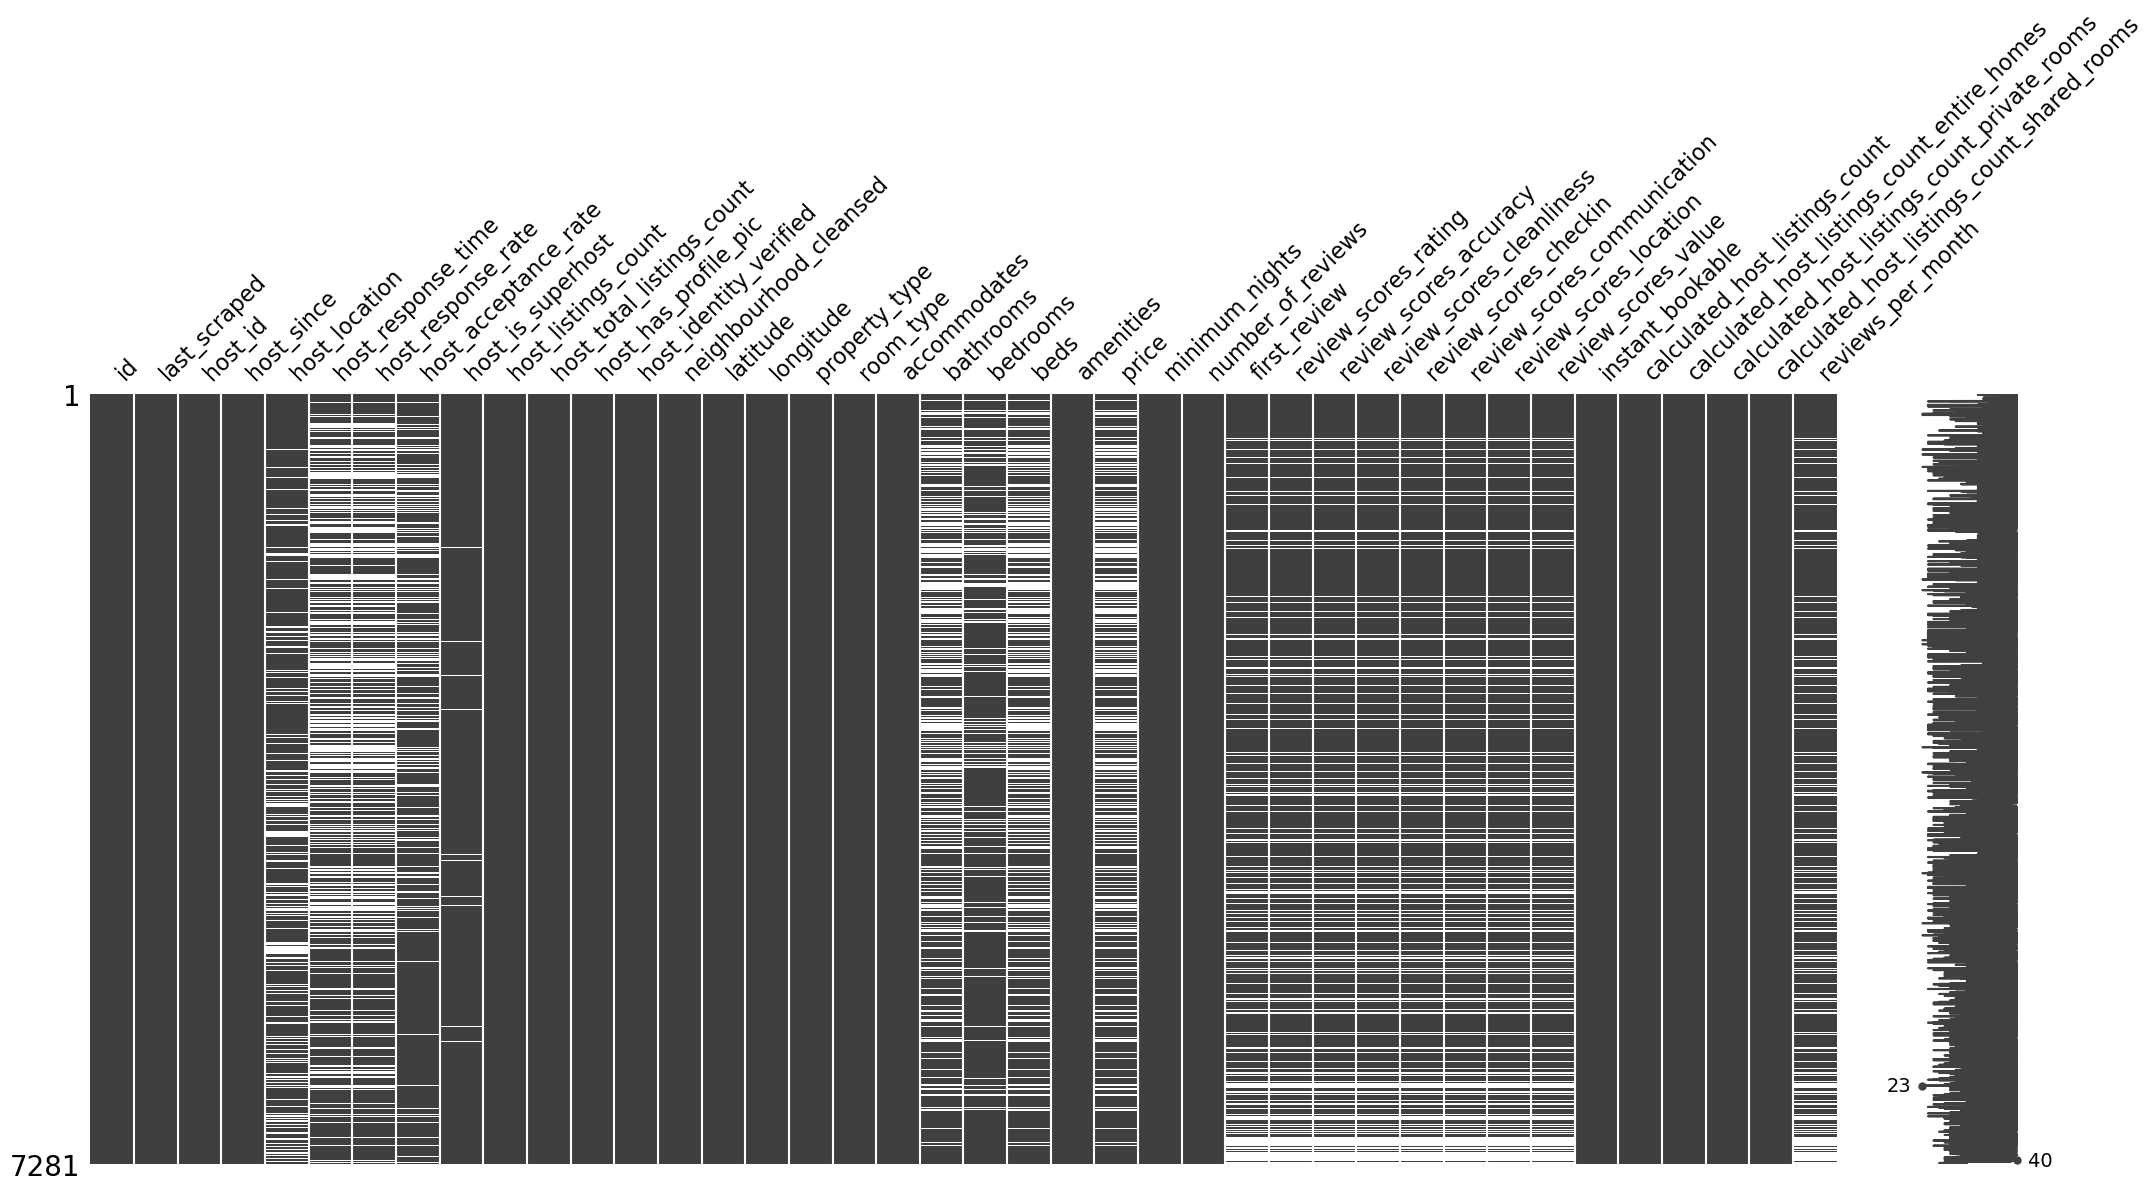

In [139]:
import missingno as msno

msno.matrix(df)

<Axes: >

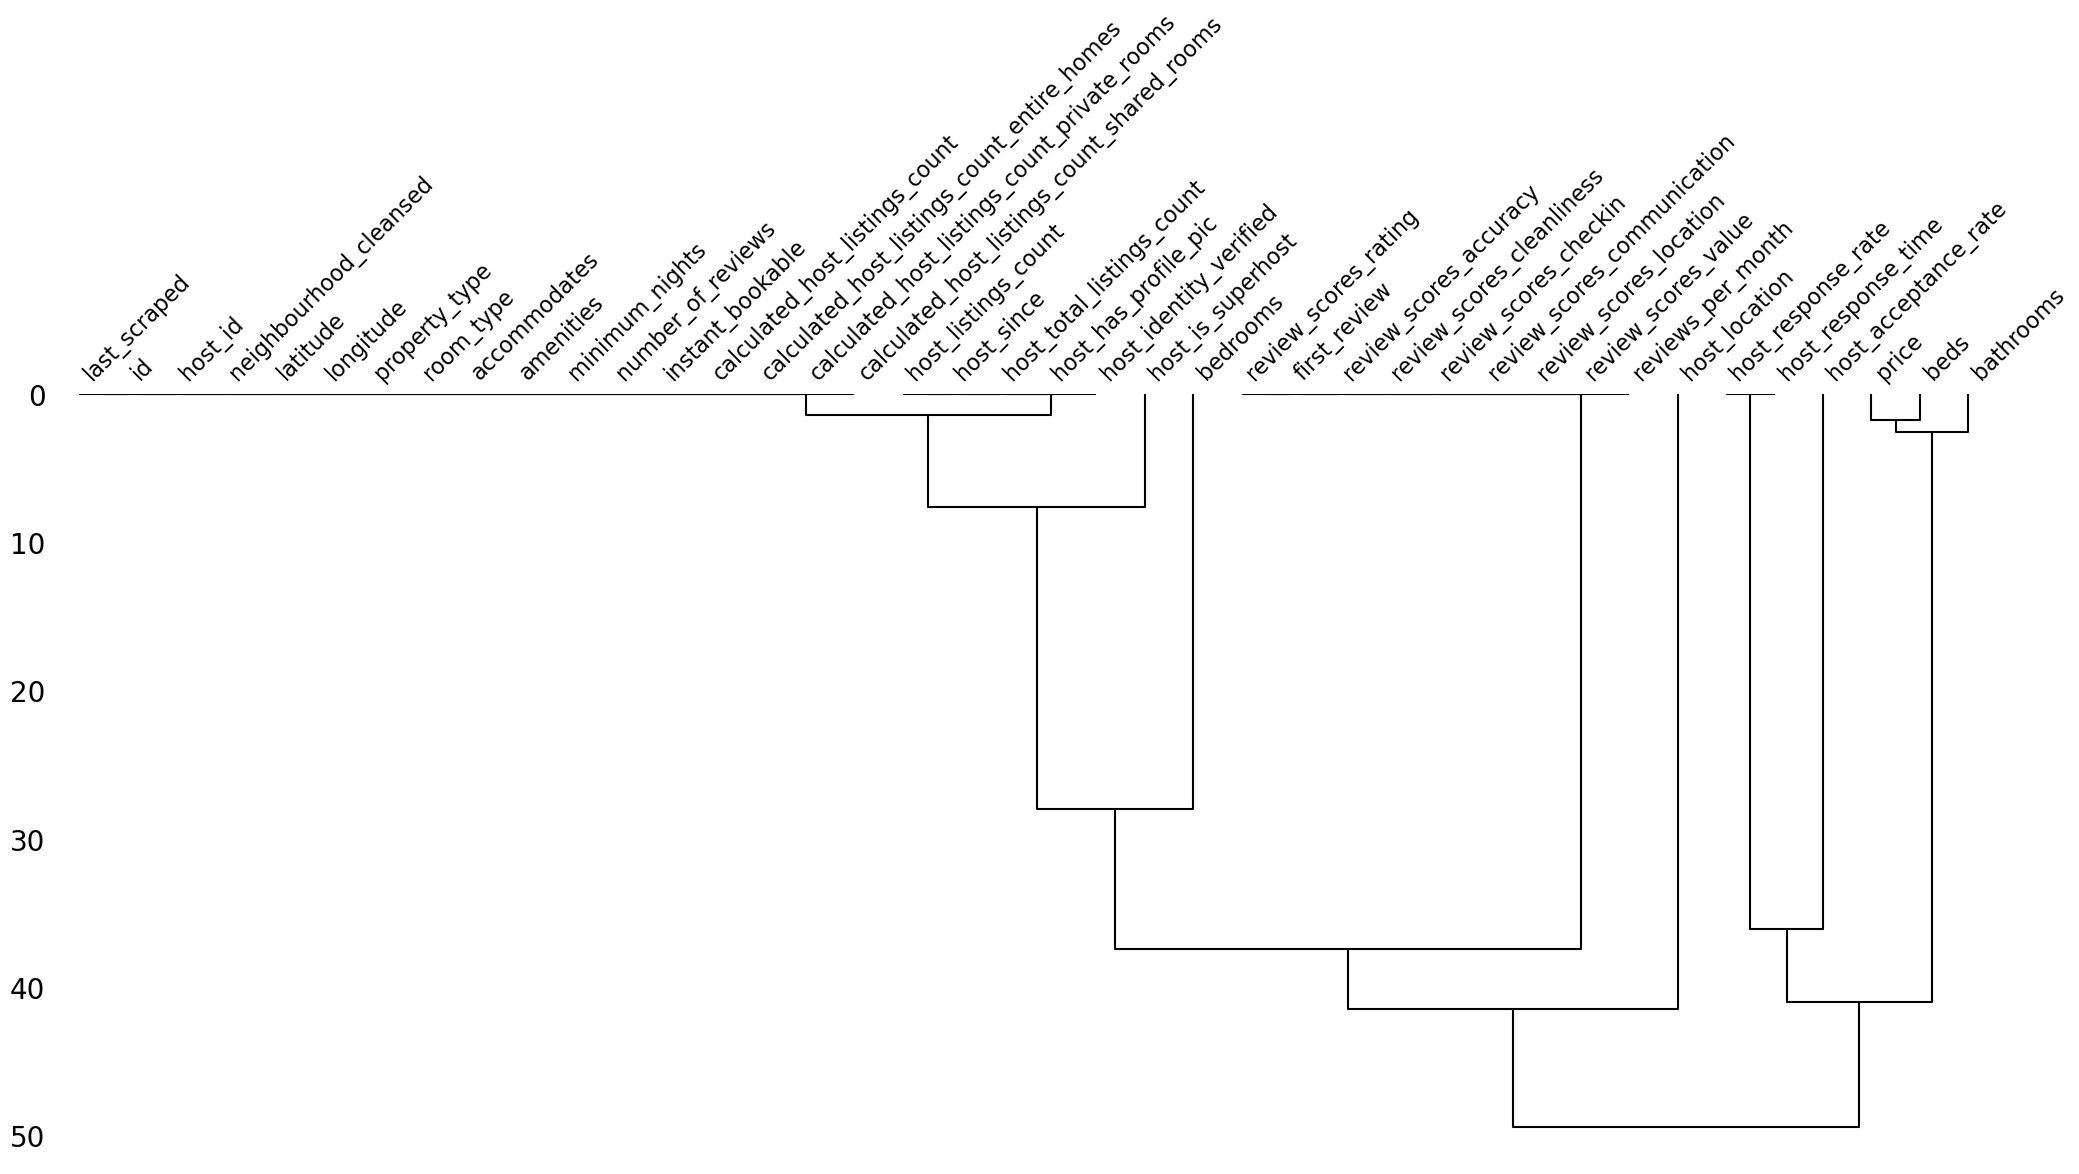

In [140]:
msno.dendrogram(df)

In [141]:
df.columns

Index(['id', 'last_scraped', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_listings_count', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'amenities', 'price', 'minimum_nights', 'number_of_reviews',
       'first_review', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month'],
      dtype='object')

In [142]:
relevant_features = [
    'review_scores_rating',  # The target variable; review scores are a key indicator of guest satisfaction.
    'host_response_time',  # Faster response times might improve ratings.
    'host_response_rate',  # Higher response rates could indicate better service.
    'host_acceptance_rate',  # A higher acceptance rate could influence guest satisfaction.
    'host_is_superhost',  # Superhosts are generally rated higher.
    'host_listings_count',  # A higher number of listings could indicate experience, which might affect ratings.
    'host_total_listings_count',  # Similar to host_listings_count, affects perception of host's experience.
    'host_has_profile_pic',  # Hosts with profile pictures might be rated more positively.
    'host_identity_verified',  # Verified hosts might influence trust and ratings.
    'neighbourhood_cleansed',  # The neighborhood could affect guests' overall experience.
    'latitude',  # Location-related factors might impact guest satisfaction.
    'longitude',  # Similar to latitude; location can affect reviews.
    'property_type',  # Different property types might influence review scores.
    'room_type',  # Entire homes, private rooms, or shared rooms might receive different reviews.
    'accommodates',  # Larger accommodations might have different ratings than smaller ones.
    'bathrooms',  # More bathrooms could correlate with higher ratings due to convenience.
    'bedrooms',  # More bedrooms might lead to better ratings for space.
    'beds',  # More beds could influence comfort and ratings.
    'amenities',  # A rich set of amenities could improve guest satisfaction and ratings.
    'price',  # Price might influence guest expectations and the perceived value in reviews.
    'minimum_nights',  # Shorter minimum stays might impact the quality of reviews.
    'number_of_reviews',  # A higher number of reviews could indicate more consistent quality.
    'first_review',  # The date of the first review might indicate the reliability of the listing over time.
    'review_scores_accuracy',  # Directly related to how accurate the listing is, affecting overall rating.
    'review_scores_cleanliness',  # Cleanliness is a key factor in overall satisfaction.
    'review_scores_checkin',  # Smooth check-in processes could improve ratings.
    'review_scores_communication',  # Good communication often leads to better reviews.
    'review_scores_location',  # The location is often a big factor in review scores.
    'review_scores_value',  # How good the value is perceived could heavily influence ratings.
    'instant_bookable',  # Instant booking might impact guest satisfaction and ratings.
    'reviews_per_month'  # High review frequency could indicate quality and consistency.
] # generated by chat-GPT

In [143]:
matrix = cramers_v_matrix(df[relevant_features])

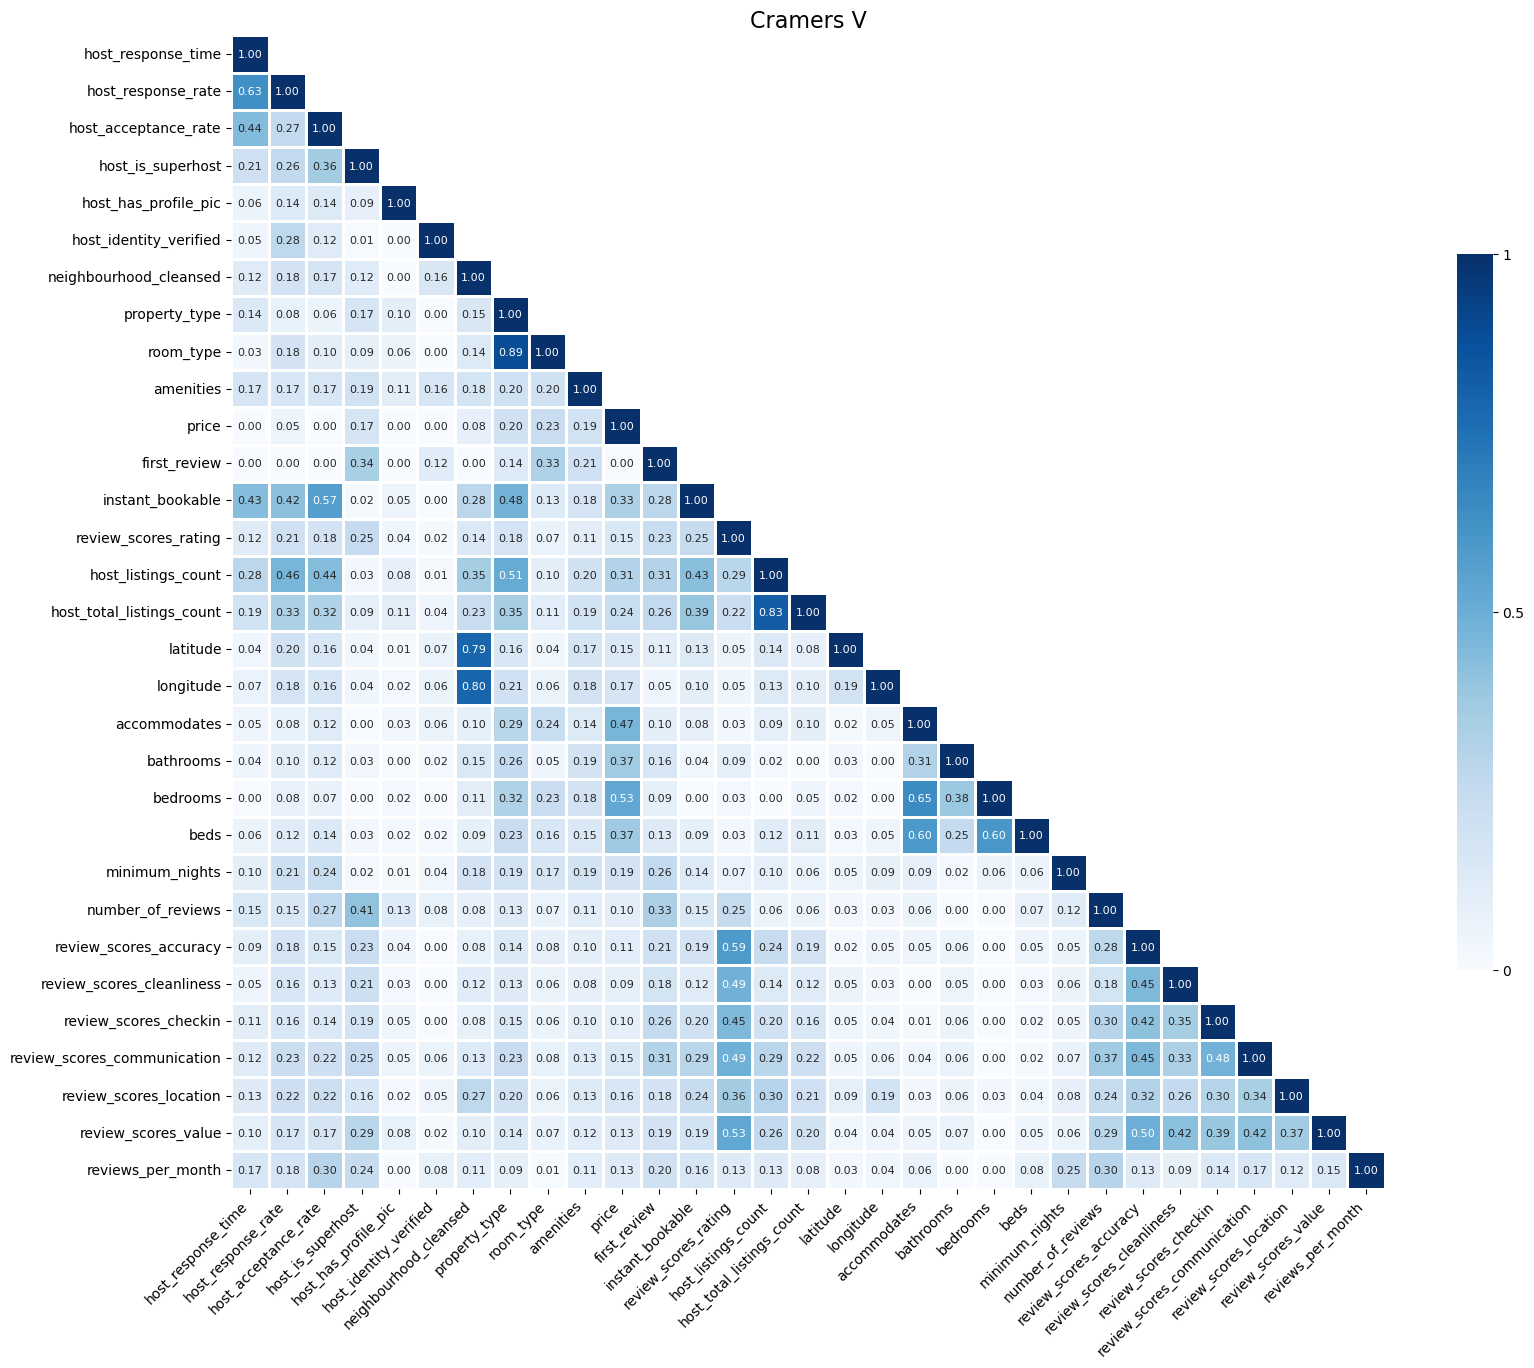

In [144]:
cat_corr_heatmap(matrix)

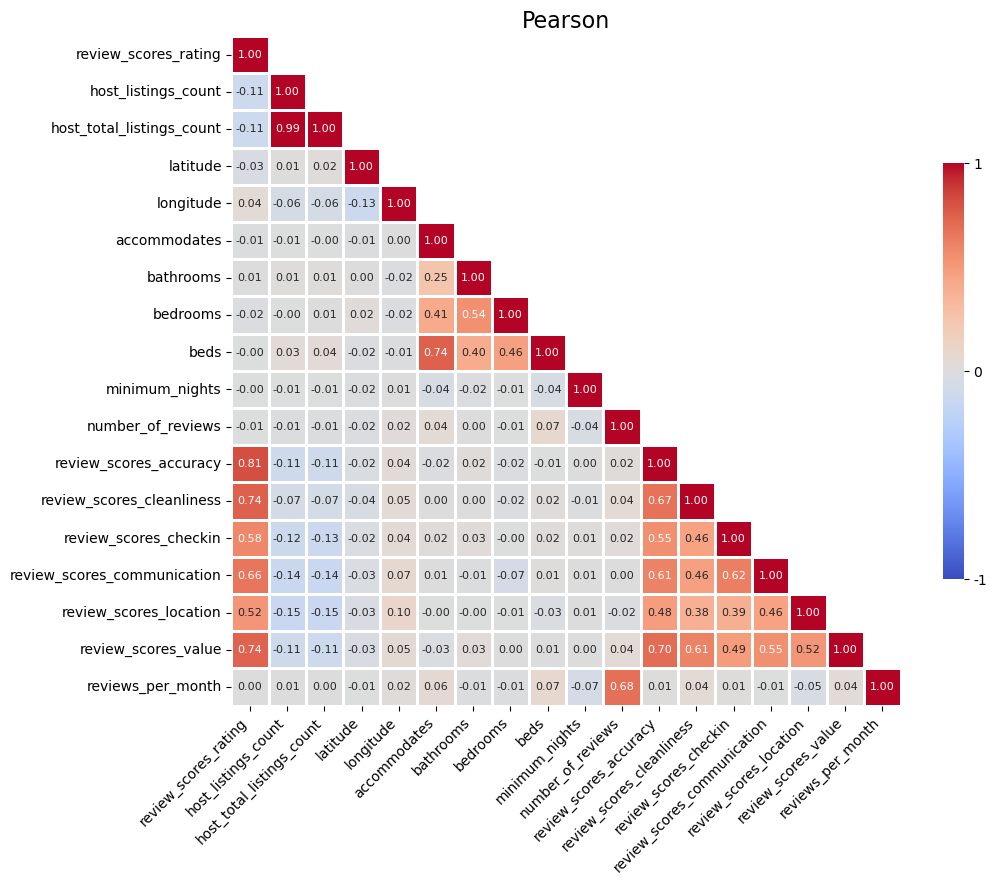

In [145]:
num_corr_heatmap(df[relevant_features].corr(numeric_only=True))

In [146]:
df.accommodates.value_counts()

2     3639
4     1198
3      877
1      860
5      259
6      253
7       55
8       55
10      28
12      16
9       13
14       8
11       8
16       6
13       4
15       2
Name: accommodates, dtype: int64

In [147]:
df.amenities.value_counts()

["TV", "Washer", "Kitchen", "Dedicated workspace", "Smoke alarm", "Wifi"]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 28
["TV", "Washer", "Kitchen", "Smoke alarm", "Wifi"]                                                                                                                                                                                                                                                         

In [148]:
df = df[relevant_features + ['id', 'host_id']].copy()

In [149]:
type(df.amenities.iloc[0])

str

In [150]:
import ast
df.amenities = df.amenities.apply(lambda x: ast.literal_eval(x))

In [151]:
df.price = df.price.replace({'\$': '', ',': ''}, regex=True).astype(float)

In [152]:

df_exploded = df.explode('amenities').reset_index(drop=True)
df_exploded.head()

,review_scores_rating,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,reviews_per_month,id,host_id
0,4.84,a few days or more,25%,6%,f,2.0,3.0,t,t,Hadern,...,4.89,4.81,4.9,4.93,4.78,4.73,f,0.78,97945,517685
1,4.84,a few days or more,25%,6%,f,2.0,3.0,t,t,Hadern,...,4.89,4.81,4.9,4.93,4.78,4.73,f,0.78,97945,517685
2,4.84,a few days or more,25%,6%,f,2.0,3.0,t,t,Hadern,...,4.89,4.81,4.9,4.93,4.78,4.73,f,0.78,97945,517685
3,4.84,a few days or more,25%,6%,f,2.0,3.0,t,t,Hadern,...,4.89,4.81,4.9,4.93,4.78,4.73,f,0.78,97945,517685
4,4.84,a few days or more,25%,6%,f,2.0,3.0,t,t,Hadern,...,4.89,4.81,4.9,4.93,4.78,4.73,f,0.78,97945,517685


In [153]:
df_exploded.shape

(192932, 33)

In [154]:
amenity_counts = df_exploded.groupby('amenities').agg(
    count=('amenities', 'size'),
    mean_rating=('review_scores_rating', 'mean'),
    mean_value_rating=('review_scores_value', 'mean'),
    average_price=('price', 'mean')
).reset_index().sort_values('count', ascending=False)
amenity_counts.head(20)

,amenities,count,mean_rating,mean_value_rating,average_price
1869,Wifi,6527,4.785979,4.629382,183.990143
1238,Kitchen,6485,4.787091,4.628049,177.651963
1703,Smoke alarm,6318,4.791663,4.634804,182.637209
1128,Hot water,4996,4.802205,4.644939,172.116449
1084,Hair dryer,4939,4.806064,4.649122,179.711069
706,Essentials,4816,4.799723,4.643059,175.202947
655,Dishes and silverware,4631,4.800960,4.641795,173.495826
1092,Hangers,4334,4.800222,4.648914,173.567338
438,Bed linens,4317,4.803599,4.642205,175.504848
644,Dedicated workspace,4148,4.795107,4.631244,173.039090


In [155]:
amenity_counts.head(100).to_csv('data/amenity_counts.csv', index=False)

In [156]:
amenity_counts[amenity_counts['count'] > 500].sort_values('average_price', ascending=False).head(20)

,amenities,count,mean_rating,mean_value_rating,average_price
533,Carbon monoxide alarm,1600,4.770650,4.617291,217.154968
1466,Paid parking on premises,1024,4.740688,4.574403,214.001328
892,Fire extinguisher,1690,4.747777,4.597996,211.405490
1688,Single level home,963,4.834313,4.677446,208.342062
1489,Patio or balcony,768,4.810132,4.648182,206.418552
387,BBQ grill,610,4.818433,4.668532,206.171053
1767,TV,3418,4.769803,4.614003,205.825712
590,Coffee maker: Nespresso,588,4.831143,4.656531,201.976526
1506,Portable fans,761,4.812521,4.655798,200.836364
897,First aid kit,1972,4.801367,4.653863,199.131655


In [157]:
amenity_counts[amenity_counts['count'] > 500].sort_values('mean_value_rating', ascending=False)

,amenities,count,mean_rating,mean_value_rating,average_price
459,Blender,1111,4.856589,4.704843,184.770213
479,Books and reading material,1357,4.857838,4.702013,181.435870
465,Board games,519,4.849719,4.698636,190.515244
410,Baking sheet,2030,4.853823,4.696476,189.278943
1418,Outdoor furniture,1111,4.837810,4.689780,193.332418
...,...,...,...,...,...
892,Fire extinguisher,1690,4.747777,4.597996,211.405490
1297,Long term stays allowed,1892,4.759191,4.597093,169.704513
1333,Mini fridge,536,4.761258,4.583959,151.375309
1492,Pets allowed,1182,4.740000,4.576048,190.460414


In [158]:
top_amenities = amenity_counts[amenity_counts['count'] > 500].sort_values('average_price', ascending=False).amenities

In [159]:
df_exploded.loc[df_exploded.amenities == 'Blender', 'review_scores_rating'].mean()

4.85658883248731

In [160]:
df_exploded.loc[df_exploded.amenities != 'Board games', 'review_scores_rating'].mean()

4.806261842160177

In [ ]:
for amenity in top_amenities:
    with_amenity = df_exploded[df_exploded['amenities'] == amenity].drop_duplicates(subset='id')
    without_amenity = df_exploded[~df_exploded['id'].isin(with_amenity['id'])].drop_duplicates(subset='id')
    with_mean = with_amenity['price'].mean()
    without_mean = without_amenity['price'].mean()
    if with_mean > without_mean:
        print(f'{amenity}: ${with_mean - without_mean:.2f}')

Carbon monoxide alarm: $44.90
Paid parking on premises: $37.26
Fire extinguisher: $39.34
Single level home: $29.47
Patio or balcony: $26.19
BBQ grill: $25.55
TV: $45.42
Coffee maker: Nespresso: $21.21
Portable fans: $20.55
First aid kit: $23.31
Private patio or balcony: $18.18
Dishwasher: $23.59
Private entrance: $13.61
Garden view: $12.14
Outdoor furniture: $12.59
Board games: $8.42
Pets allowed: $9.42
Elevator: $10.23
Dryer: $7.66
Baking sheet: $9.07
TV with standard cable: $6.08
Freezer: $7.72
Self check-in: $5.48
Shower gel: $4.64
Outdoor dining area: $3.28
Blender: $2.46
Wine glasses: $3.21
Coffee: $1.83
Wifi: $13.31
Microwave: $1.36
Shampoo: $1.47
Dining table: $0.07
